In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Challenge: Demand for Shelter
Predicting the future is always difficult.  
In this interesting case study, we use Prophet to predict the Demand for Shelter in New York City.  
As well, we will learn about cross-validation and Parameter Tuning in Time Series

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/thethien8a/Forecasting/refs/heads/main/study-2/course-material/Modern%20Time%20Series%20Forecasting%20Techniques/CAPSTONE%20PROJECT_%20Prophet/DHS_weekly.csv')

### Quick glance

In [ ]:
df.head()

,Date,Total Individuals in Shelter,Easter,Thanksgiving,Christmas,Temperature
0,1/5/2014,354354,0,0,0,0.848000
1,1/12/2014,358103,0,0,0,3.257143
2,1/19/2014,359491,0,0,0,5.632857
3,1/26/2014,362880,0,0,0,-1.850000
4,2/2/2014,364125,0,0,0,1.177143


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          366 non-null    object 
 1   Total Individuals in Shelter  366 non-null    int64  
 2   Easter                        366 non-null    int64  
 3   Thanksgiving                  366 non-null    int64  
 4   Christmas                     366 non-null    int64  
 5   Temperature                   366 non-null    float64
dtypes: float64(1), int64(4), object(1)
memory usage: 17.3+ KB


In [ ]:
df.describe()

,Total Individuals in Shelter,Easter,Thanksgiving,Christmas,Temperature
count,366.000000,366.000000,366.000000,366.000000,366.000000
mean,405042.808743,0.019126,0.019126,0.019126,14.842424
std,19375.509125,0.137154,0.137154,0.137154,8.511113
min,212514.000000,0.000000,0.000000,0.000000,-4.318571
25%,397040.250000,0.000000,0.000000,0.000000,7.503571
50%,408495.000000,0.000000,0.000000,0.000000,14.918571
75%,418908.750000,0.000000,0.000000,0.000000,22.792143
max,428607.000000,1.000000,1.000000,1.000000,28.535714


###  Convert data types

In [ ]:
df = df.rename(columns = {
    'Date':'ds',
    'Total Individuals in Shelter':'y'
})

In [ ]:
df.ds = pd.to_datetime(df.ds)

In [ ]:
# Check whether weekly data
df.ds.diff().value_counts()

,count
ds,
7 days,365


-> Data 7 days continously

In [ ]:
df.head()

,ds,y,Easter,Thanksgiving,Christmas,Temperature
0,2014-01-05,354354,0,0,0,0.848000
1,2014-01-12,358103,0,0,0,3.257143
2,2014-01-19,359491,0,0,0,5.632857
3,2014-01-26,362880,0,0,0,-1.850000
4,2014-02-02,364125,0,0,0,1.177143


### Exploratory Data Analysis

In [ ]:
def plot_bar(df, col):
    sns.set_style("whitegrid")
    value_counts = df[col].value_counts()
    plt.figure(figsize=(10, 6))
    bars = plt.bar(value_counts.index, value_counts.values,
                   color=sns.color_palette("viridis", len(value_counts)))
    plt.title(f'Distribution of {col}', fontsize=14, pad=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

def hist_plot(df, col):
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, bins=30, kde=True, color='teal')
    plt.title(f'Histogram of {col}', fontsize=14, pad=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

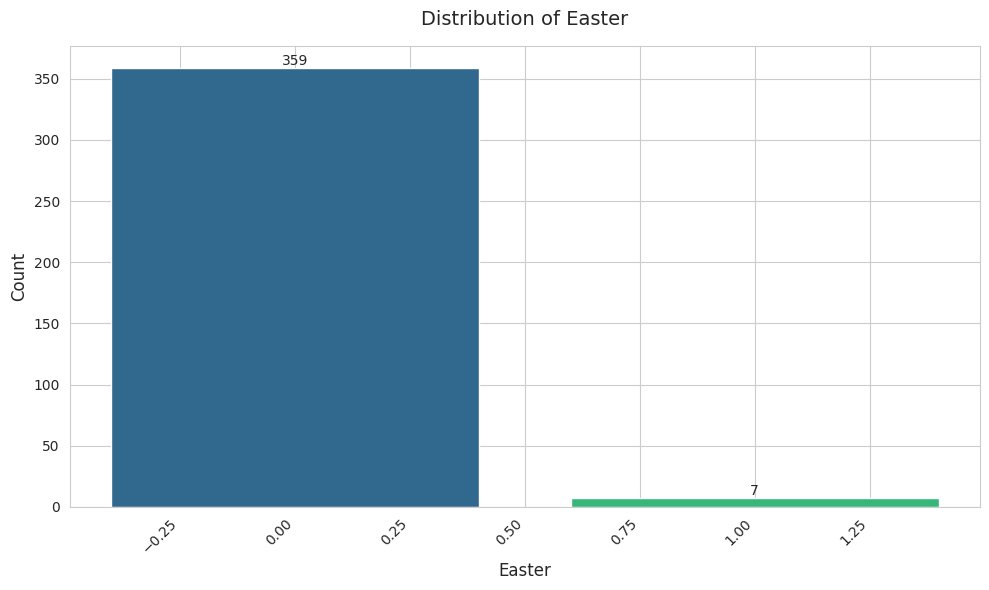

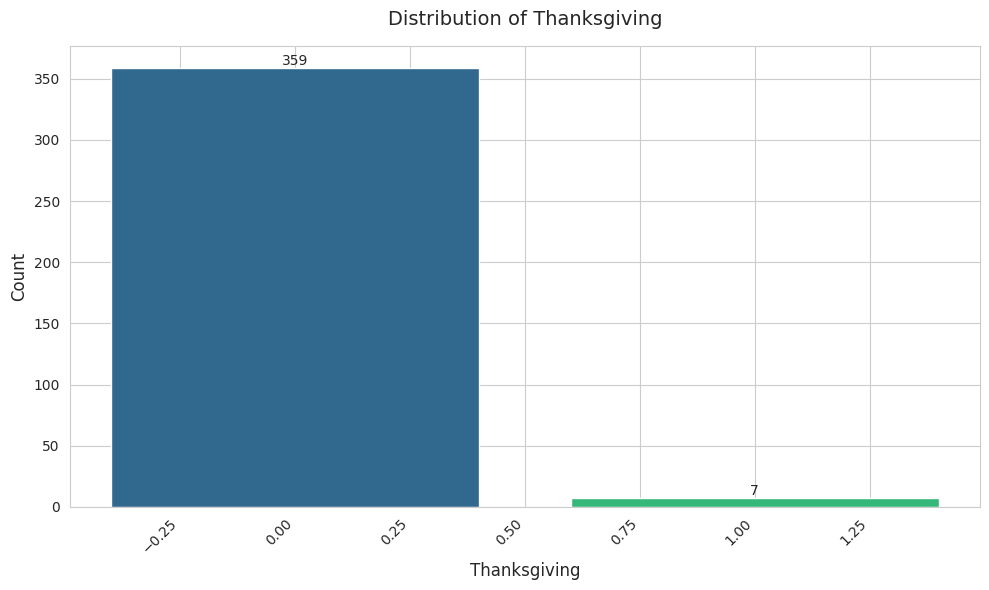

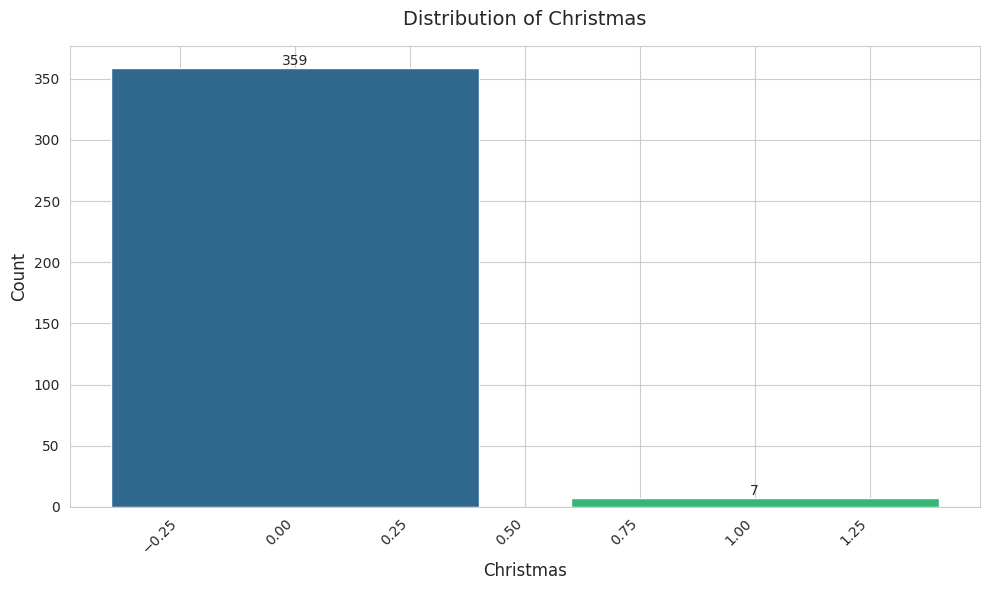

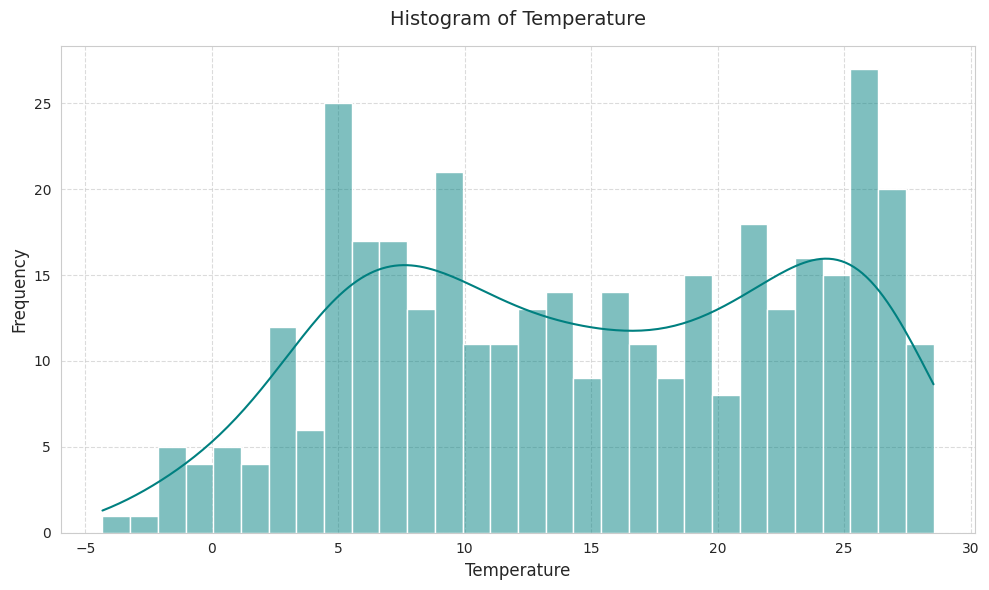

In [ ]:
# First, i check all the values of columns Easter, Thanksgiving, Christmas, Temperature
for col in ["Easter","Thanksgiving","Christmas"]:
    plot_bar(df, col)
hist_plot(df,"Temperature")

In [ ]:
df_temp = df.copy().set_index('ds')

In [ ]:
df_temp.index.freq = 'W'

In [ ]:
df_temp.index

DatetimeIndex(['2014-01-05', '2014-01-12', '2014-01-19', '2014-01-26',
               '2014-02-02', '2014-02-09', '2014-02-16', '2014-02-23',
               '2014-03-02', '2014-03-09',
               ...
               '2020-11-01', '2020-11-08', '2020-11-15', '2020-11-22',
               '2020-11-29', '2020-12-06', '2020-12-13', '2020-12-20',
               '2020-12-27', '2021-01-03'],
              dtype='datetime64[ns]', name='ds', length=366, freq='W-SUN')

In [ ]:
max(df_temp.index)

Timestamp('2021-01-03 00:00:00')

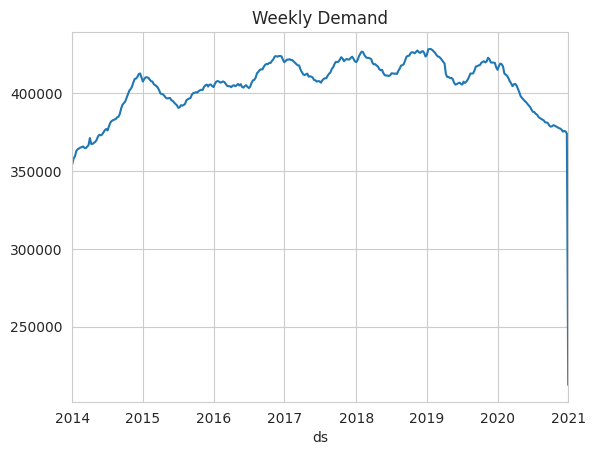

In [ ]:
df_temp['y'].plot(title='Weekly Demand');

In [ ]:
# in 2021, what is that ?
df_temp[df_temp.index.year == 2021]
df_temp = df_temp[df_temp.index.year != 2021]

-> Only have one record, and that record drop down so much. For the performance of model to forecast, i will remove it

In [ ]:
df = df[df.ds.dt.year != 2021]

In [ ]:
# All plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot

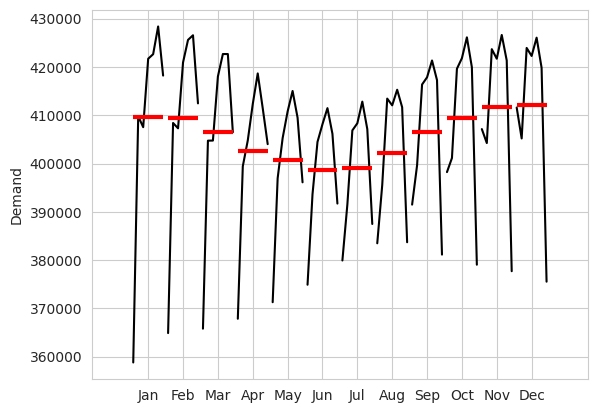

In [ ]:
month_plot(df_temp['y'].resample('ME').median(), ylabel="Demand");

-> Comment:
+ Month 1 with the value maybe fall down min to 360000. See what problem
+ Most month median between 400k to 410k
+ The data shows very clear cyclical behavior - each month has periods of sharp increases and decreases

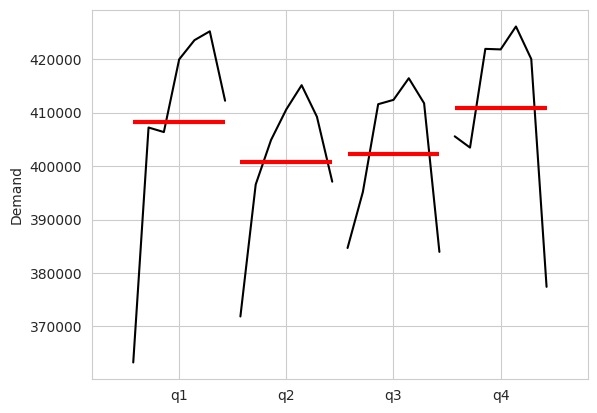

In [ ]:
quarter_plot(df_temp['y'].resample('QE').mean(), ylabel="Demand");

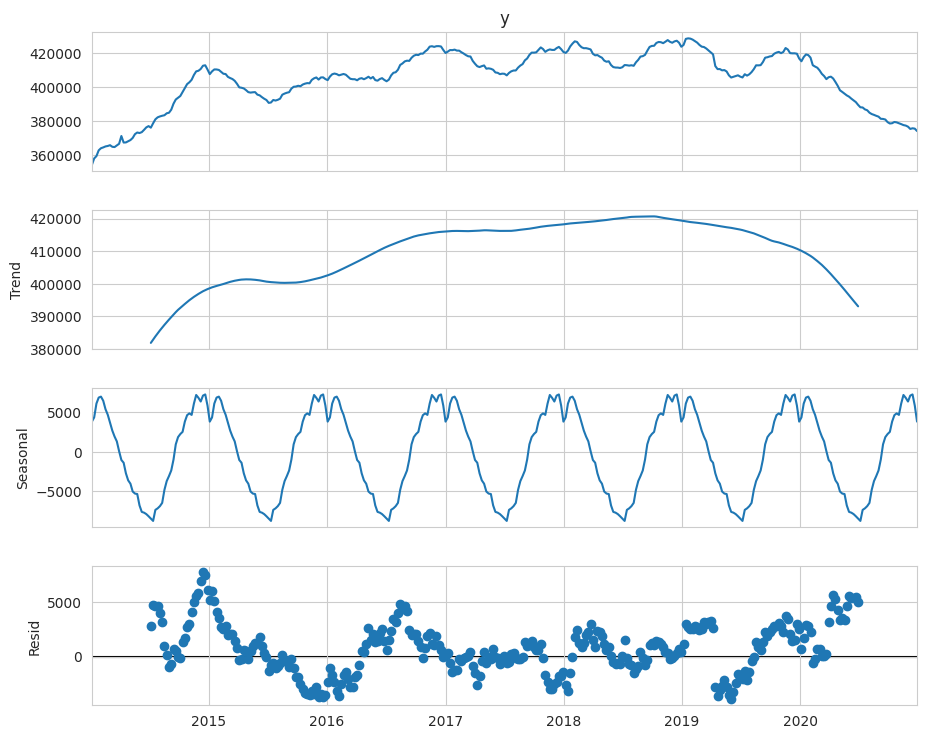

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df_temp['y'], model='additive')
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

-> Trend no stable, up and down

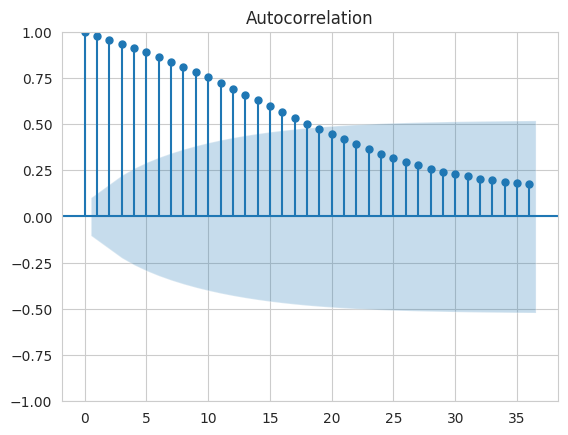

In [ ]:
# ACF
plot_acf(df_temp['y'], lags=36);

-> Non-stationary (because of the slow dropping)

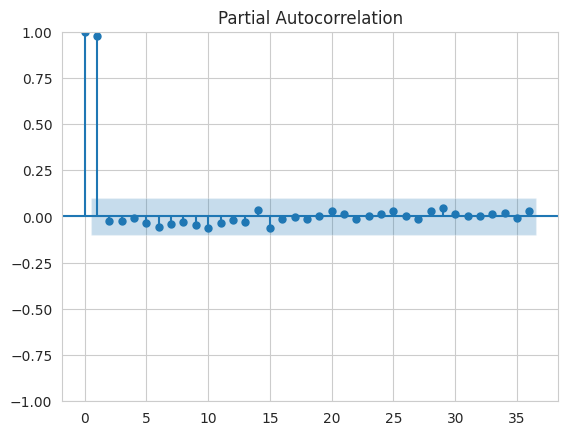

In [ ]:
# PACF
plot_pacf(df_temp['y'], lags=36);

-> Only yesterday can predict today  
-> Drop suddenly in 2, maybe AR(2) - ARIMA(2,1,q)

In [ ]:
Easter_date = df_temp[df_temp["Easter"] == 1].index
Thanksgiving_date = df_temp[df_temp["Thanksgiving"] == 1].index
Christmas_date = df_temp[df_temp["Christmas"] == 1].index

easter = pd.DataFrame({
  'holiday': 'easter',
  'ds': Easter_date,
  'lower_window': -3,
  'upper_window': 1,
})

thanksgiving = pd.DataFrame({
  'holiday': 'thanksgiving',
  'ds': Thanksgiving_date,
  'lower_window': -4,
  'upper_window': 4,
})

christmas = pd.DataFrame({
  'holiday': 'christmas',
  'ds': Christmas_date,
  'lower_window': -15,
  'upper_window': 7,
})

all_holidays = pd.concat((easter, thanksgiving, christmas))

In [ ]:
all_holidays

,holiday,ds,lower_window,upper_window
0,easter,2014-04-20,-3,1
1,easter,2015-04-05,-3,1
2,easter,2016-03-27,-3,1
3,easter,2017-04-16,-3,1
4,easter,2018-04-01,-3,1
5,easter,2019-04-21,-3,1
6,easter,2020-04-12,-3,1
0,thanksgiving,2014-11-30,-4,4
1,thanksgiving,2015-11-29,-4,4
2,thanksgiving,2016-11-27,-4,4


In [ ]:
df = df.drop(columns=['Easter', 'Thanksgiving', 'Christmas'])

In [ ]:
from prophet import Prophet
df.head()

,ds,y,Temperature
0,2014-01-05,354354,0.848000
1,2014-01-12,358103,3.257143
2,2014-01-19,359491,5.632857
3,2014-01-26,362880,-1.850000
4,2014-02-02,364125,1.177143


In [ ]:
train_df = df.iloc[:-13]
test_df = df.iloc[-13:]

In [ ]:
train_df

,ds,y,Temperature
0,2014-01-05,354354,0.848000
1,2014-01-12,358103,3.257143
2,2014-01-19,359491,5.632857
3,2014-01-26,362880,-1.850000
4,2014-02-02,364125,1.177143
...,...,...,...
347,2020-08-30,382654,27.560000
348,2020-09-06,381387,25.552857
349,2020-09-13,381309,24.185714
350,2020-09-20,380963,20.405714


In [ ]:
def plot_time_series(df1,y_df1,df2,y_df2):
  plt.figure(figsize=(10,5))
  plt.plot(df1.ds, df1[f'{y_df1}'])
  plt.plot(df2.ds, df2[f"{y_df2}"])
  plt.title("Time Series Plot")
  plt.xlabel("Date")
  plt.ylabel("Value")
  plt.grid(True)
  plt.show()

In [ ]:
# Initialize model
model = Prophet(
    holidays=all_holidays,
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=True
)

In [ ]:
model.add_regressor('Temperature')

In [ ]:
# 5. HUẤN LUYỆN MÔ HÌNH (FIT)
print("\nBắt đầu huấn luyện mô hình...")
model.fit(train_df)
print("Huấn luyện hoàn tất.")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfc1wiytn/ctlmcv6i.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfc1wiytn/mzx_k6z7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=43298', 'data', 'file=/tmp/tmpfc1wiytn/ctlmcv6i.json', 'init=/tmp/tmpfc1wiytn/mzx_k6z7.json', 'output', 'file=/tmp/tmpfc1wiytn/prophet_modelduno445n/prophet_model-20250827153653.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:36:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing



Bắt đầu huấn luyện mô hình...


15:36:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Huấn luyện hoàn tất.


In [ ]:
from prophet.utilities import regressor_coefficients
regressor_coefficients(model)

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,Temperature,additive,14.915834,-5.551584,-5.551584,-5.551584


In [ ]:
# Predict over the future dataframe
forecast = model.predict(df[["ds","Temperature"]])

In [ ]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Temperature,Temperature_lower,Temperature_upper,additive_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
360,2020-11-29,390337.568794,392839.259909,399445.846302,389789.154333,390860.428285,11.857263,11.857263,11.857263,5779.176838,...,-1883.98331,-1883.98331,-1883.98331,8292.597537,8292.597537,8292.597537,0.0,0.0,0.0,396116.745632
361,2020-12-06,389936.618888,392677.374820,399038.196025,389267.123719,390591.780790,26.886193,26.886193,26.886193,5956.258222,...,-1883.98331,-1883.98331,-1883.98331,7813.355338,7813.355338,7813.355338,0.0,0.0,0.0,395892.877110
362,2020-12-13,389535.668983,393118.270352,399895.462429,388734.416797,390371.922307,37.235931,37.235931,37.235931,6893.697489,...,-1883.98331,-1883.98331,-1883.98331,6561.012561,6561.012561,6561.012561,0.0,0.0,0.0,396429.366472
363,2020-12-20,389134.719077,391893.246006,399008.792402,388148.991494,390160.969529,63.177688,63.177688,63.177688,6320.863168,...,-1883.98331,-1883.98331,-1883.98331,5114.306112,5114.306112,5114.306112,0.0,0.0,0.0,395455.582246
364,2020-12-27,388733.769172,389331.460555,396253.055031,387616.706687,389927.834416,41.114109,41.114109,41.114109,3993.255019,...,-1883.98331,-1883.98331,-1883.98331,4310.184720,4310.184720,4310.184720,0.0,0.0,0.0,392727.024191


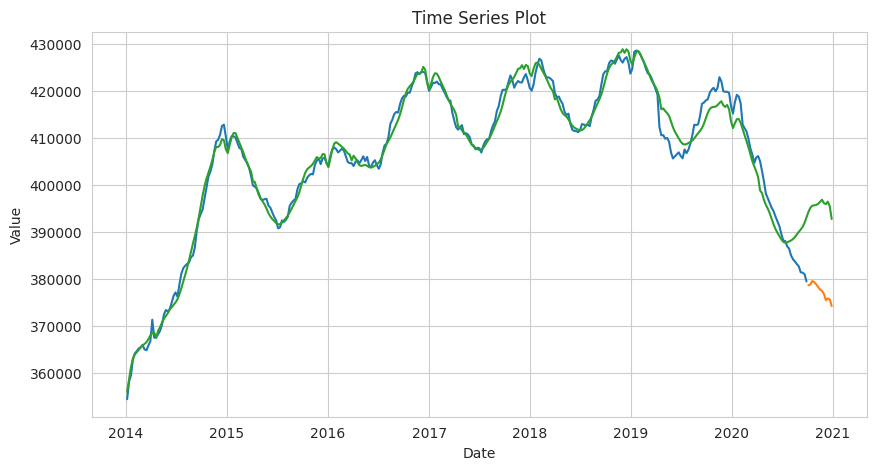

In [ ]:
# See the predict
plt.figure(figsize=(10,5))
plt.plot(train_df.ds, train_df["y"])
plt.plot(test_df.ds, test_df["y"])
plt.plot(forecast.ds, forecast["yhat"])
plt.title("Time Series Plot")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [ ]:
error = (forecast["yhat"] - test_df["y"]).abs()

In [ ]:
mae = np.mean((forecast["yhat"][-13:]-test_df["y"]).abs())

In [ ]:
print(mae)

18138.1301592259
